# Sliding Block Puzzle Environment Demo

This notebook demonstrates the Sliding Block (Klotski) environment.

In [1]:
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy)

In [2]:
env = gym.make("sliding_block/easy")
print(f"Board size: {env.unwrapped.board_size}")
print(f"Number of shuffle moves: {env.unwrapped.num_shuffle_moves}")
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names()}")
print(f"Directions: 0=up, 1=right, 2=down, 3=left")

Board size: (5, 4)
Number of shuffle moves: 30
Action Space: FuncConditional(['move', 'stop'])
Available actions: ['move', 'stop']
Directions: 0=up, 1=right, 2=down, 3=left


## 2. Reset and View Initial State

Observation shape: (5, 4)
Board configuration:
[[ 3  1  1  4]
 [ 3  1  1  4]
 [ 5  2  2  6]
 [ 5  9 10  6]
 [ 7  0  0  8]]

Number of blocks: 10


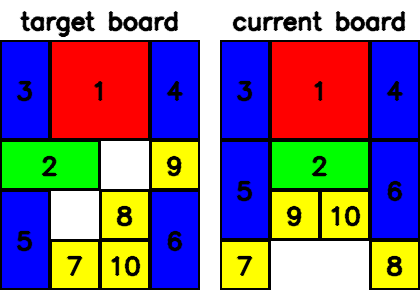


Task Prompt:
You are solving a 5x4 sliding block puzzle (Klotski). The puzzle consists of rectangular blocks that can be moved in four directions. Your goal is to rearrange the blocks to match the target configuration.
You see two boards side-by-side:
- Left: the target configuration
- Right: the current configuration that you need to rearrange


Available actions:
1. 'move': Move a block in one of four directions. Format: `('move', (block_id, direction))` where:
   - block_id is the number of the block to move (1-10)
   - direction is 0=up, 1=right, 2=down, 3=left
2. 'stop': End the puzzle solving session. Format: `('stop', 'stop')`

Success: You succeed if all blocks are in their target positions when you stop.

Please respond with exactly one action and its arguments in the specified format. For example:
- To move block 1 up: `('move', (1, 0))`
- To move block 2 right: `('move', (2, 1))`
- To move block 3 down: `('move', (3, 2))`
- To move block 4 left: `('move', (4, 3))`
- To stop

In [3]:
obs, info = env.reset(seed=42)
print(f"Observation shape: {obs.shape}")
print(f"Board configuration:")
print(obs)
print(f"\nNumber of blocks: {len(env.unwrapped.blocks)}")

# Render both target and current configuration
frame = env.render()
display(Image.fromarray(frame))
print(f"\nTask Prompt:\n{env.unwrapped.get_prompt()}")

## 3. Test Manual Actions

Action: ('move', (1, 2))
Feedback: The action (1, 2) is not valid because the block 1 cannot move in the direction down.


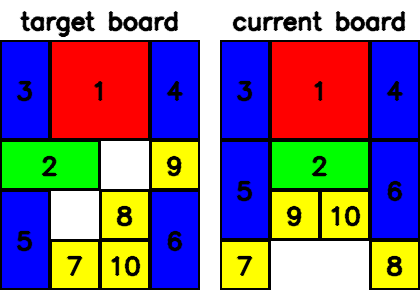

In [4]:
# Try moving different blocks - move block 1 down (direction 2)
action = "('move', (1, 2))"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Feedback: {info.get('env_feedback', 'N/A')}")
frame = env.render()
display(Image.fromarray(frame))

## 4. Test Solver

Initial configuration:


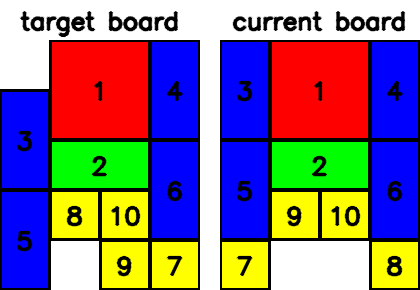


Solver generated 15 actions
First few actions: ["('move', (7, 1))", "('move', (5, 2))", "('move', (2, 3))", "('move', (8, 3))", "('move', (10, 0))"]

Step 1: ('move', (7, 1))


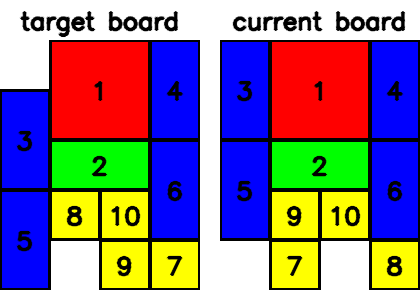


Step 2: ('move', (5, 2))


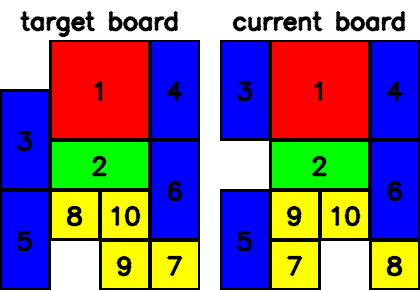


Step 3: ('move', (2, 3))


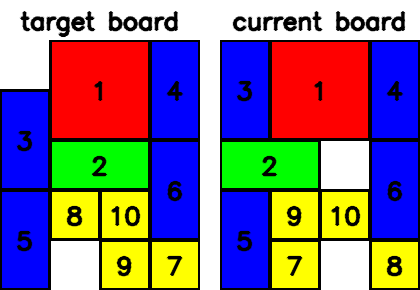


Step 11: ('move', (9, 1))


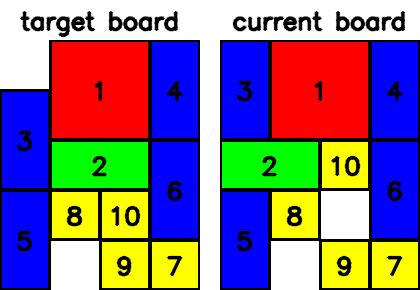


Step 15: ('stop', 'stop')


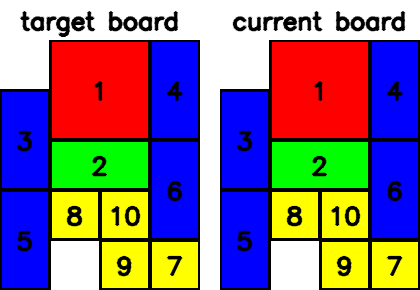


✓ Puzzle solved! Reward: 1.0


In [8]:
env = gym.make("sliding_block/easy")
obs, info = env.reset(seed=100)
print("Initial configuration:")
frame = env.render()
display(Image.fromarray(frame))

# Get solver actions
actions = env.unwrapped.solve()
print(f"\nSolver generated {len(actions)} actions")
print(f"First few actions: {actions[:5]}")

# Execute solver actions (show progress)
for i, action in enumerate(actions):
    obs, reward, terminated, truncated, info = env.step(action)
    if i < 3 or i % 10 == 0 or terminated:  # Show first 3, every 10th, and final
        print(f"\nStep {i+1}: {action}")
        frame = env.render()
        display(Image.fromarray(frame))
        if terminated:
            frame = env.render()
            print(f"\n✓ Puzzle solved! Reward: {reward}")
    if terminated:
        break

env.close()

## 5. Test Hard Difficulty (More Shuffling)

Hard difficulty - 90 shuffle moves (vs easy: 30)


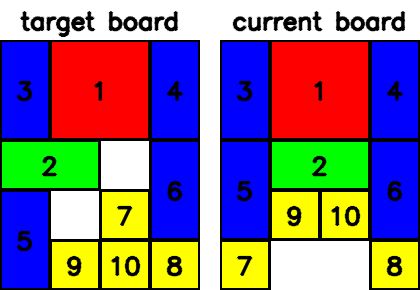


Solution requires 10 moves


In [9]:
env_hard = gym.make("sliding_block/hard")
obs, info = env_hard.reset(seed=42)
print(f"Hard difficulty - {env_hard.unwrapped.num_shuffle_moves} shuffle moves (vs easy: 30)")
frame = env_hard.render()
display(Image.fromarray(frame))

# Get solution
actions = env_hard.unwrapped.solve()
print(f"\nSolution requires {len(actions)} moves")

env_hard.close()